In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import load_and_prep_data, run_validation_loop, HawkesModel
from src import plot_user_timeline, analyze_user_intensity, plot_parameter_distributions

In [12]:
sequences = load_and_prep_data('data/raw/retail_data.csv')
factory_reg = lambda p: HawkesModel(baseline_model=p, penalty_weight=50.0)

df_results = run_validation_loop(sequences, model_factory=factory_reg, label="Regularized", min_events=20)

Running 'Regularized': N=107


100%|██████████| 107/107 [00:00<00:00, 147.12it/s]


In [13]:
class ScaledPoisson:
    def __init__(self, baseline):
        self.baseline = baseline
        self.mu = 1.0
        self.kernel = 'scaled'
        self.penalty_weight = 0

    def fit(self, times):
        T = (times[-1] - times[0]).total_seconds() / 3600
        if T < 1e-3: T = 1e-3
        
        check_points = np.linspace(times[0].timestamp(), times[-1].timestamp(), 10)
        check_dates = pd.to_datetime(check_points, unit='s')
        base_rates = [self.baseline.get_intensity(t) for t in check_dates]
        self.base_integral = np.mean(base_rates) * T
        
        self.mu = len(times) / self.base_integral if self.base_integral > 0 else 1.0
        return self

    @property
    def params(self):
        return [self.mu, 0.0, 1.0, 1.0]

    def get_intensity(self, t, history=None):
        return self.baseline.get_intensity(t) * self.mu

    def nll(self, times, T_max):
        log_mu = np.log(self.mu) if self.mu > 1e-9 else -10
        
        log_base_sum = 0
        for t in times:
            lb = self.baseline.get_intensity(t)
            log_base_sum += np.log(lb) if lb > 1e-9 else -10
            
        term1 = len(times) * log_mu + log_base_sum
        term2 = self.mu * self.base_integral
        
        return -(term1 - term2)

In [14]:
print(">>> 1/2 Running Scaled Poisson (Corrected)...")
factory_scaled = lambda p: ScaledPoisson(p)
df_scaled = run_validation_loop(sequences, factory_scaled, label="Scaled", min_events=30)

print("\n>>> 2/2 Running Full Hawkes...")
factory_hawkes = lambda p: HawkesModel(p, penalty_weight=20.0, kernel='exp')
df_hawkes = run_validation_loop(sequences, factory_hawkes, label="Hawkes", min_events=30)


>>> 1/2 Running Scaled Poisson (Corrected)...
Running 'Scaled': N=46


100%|██████████| 46/46 [00:00<00:00, 2101.24it/s]



>>> 2/2 Running Full Hawkes...
Running 'Hawkes': N=46


100%|██████████| 46/46 [00:00<00:00, 104.95it/s]



Avg LL Gain: -0.1903
Win Rate (Hawkes > Scaled): 32.6%


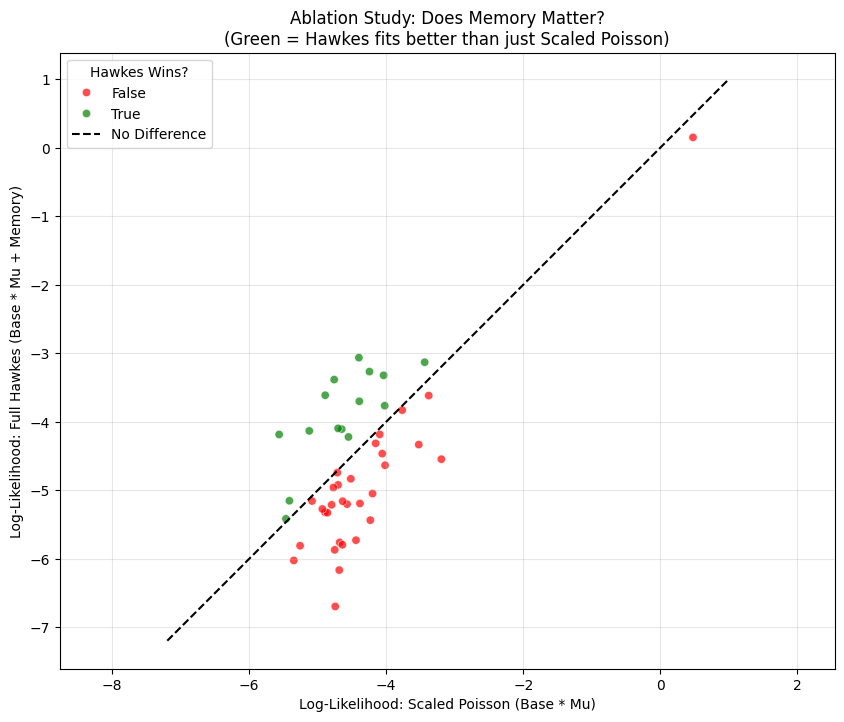

In [15]:

key_col = 'll_model'
df_comp = pd.merge(df_scaled[['user_id', key_col]], 
                   df_hawkes[['user_id', key_col]], 
                   on='user_id', suffixes=('_scaled', '_hawkes'))

df_comp['gain'] = df_comp[f'{key_col}_hawkes'] - df_comp[f'{key_col}_scaled']
avg_gain = df_comp['gain'].mean()
win_rate = (df_comp['gain'] > 0).mean()

print(f"\nAvg LL Gain: {avg_gain:.4f}")
print(f"Win Rate (Hawkes > Scaled): {win_rate:.1%}")

plt.figure(figsize=(10, 8))

sns.scatterplot(data=df_comp, x=f'{key_col}_scaled', y=f'{key_col}_hawkes', 
                hue=df_comp['gain'] > 0, palette={True: 'green', False: 'red'}, alpha=0.7)

min_val = min(df_comp[f'{key_col}_scaled'].min(), df_comp[f'{key_col}_hawkes'].min()) - 0.5
max_val = max(df_comp[f'{key_col}_scaled'].max(), df_comp[f'{key_col}_hawkes'].max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='No Difference')

plt.title(f"Ablation Study: Does Memory Matter?\n(Green = Hawkes fits better than just Scaled Poisson)")
plt.xlabel('Log-Likelihood: Scaled Poisson (Base * Mu)')
plt.ylabel('Log-Likelihood: Full Hawkes (Base * Mu + Memory)')
plt.legend(title='Hawkes Wins?')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

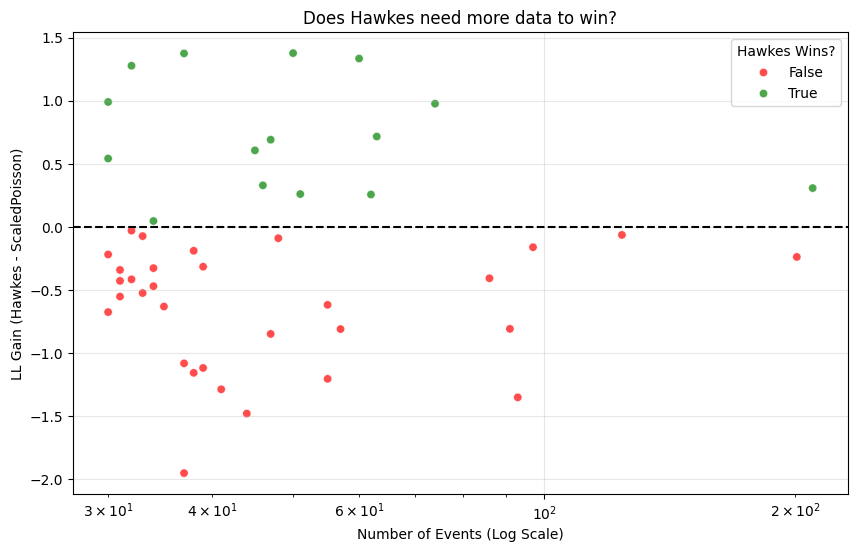

Avg Events (Hawkes Winners): 58.1
Avg Events (Poisson Winners): 53.3


In [17]:
# Смотрим зависимость выигрыша от количества событий
plt.figure(figsize=(10, 6))

# ИСПРАВЛЕНИЕ ТУТ: hue=df_comp['gain'] > 0
sns.scatterplot(data=df_comp, x=df_scaled['events'], y='gain', 
                hue=df_comp['gain'] > 0, palette={True:'green', False:'red'}, alpha=0.7)

plt.axhline(0, color='black', linestyle='--')
plt.xscale('log') 
plt.title('Does Hawkes need more data to win?')
plt.xlabel('Number of Events (Log Scale)')
plt.ylabel('LL Gain (Hawkes - ScaledPoisson)')
plt.legend(title='Hawkes Wins?')
plt.grid(True, alpha=0.3)
plt.show()

# Выводим среднее кол-во событий
events_winners = df_scaled.loc[df_comp['gain'] > 0, 'events']
events_losers = df_scaled.loc[df_comp['gain'] <= 0, 'events']

print(f"Avg Events (Hawkes Winners): {events_winners.mean():.1f}")
print(f"Avg Events (Poisson Winners): {events_losers.mean():.1f}")